# Compare TCL2, TCL4, and TCL6

Calculate the reduced dynamics of unbiased and biased spin-boson models using the standalone CPU package. This notebook introduces the shared solver, plots the three truncations, and checks a finer time grid.

From the **repository root**, install and launch JupyterLab:

```sh
python -m pip install ".[notebook]"
python -m jupyter lab examples/
```

Select the Python environment where you installed the package, then use **Run All Cells**. No TACO, CUDA, or external data files are needed. Saved plots are included for browsing on GitHub.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import fasttcl
from fasttcl import OhmicBath, prepare_model, compile_plan, solve

plt.rcParams.update({"font.size": 10, "figure.dpi": 110})
print(f"FastTCL {fasttcl.__version__}")

FastTCL 0.2.0


## Model and coupling

We use $H_{\rm int}=\lambda A\otimes B$ with $A=\sigma_z/2$ and an initial laboratory-basis state $\rho(0)=|0\rangle\langle0|$. The Hamiltonians are

$$H_{\rm unbiased}=\tfrac12\sigma_x,\qquad H_{\rm biased}=0.4\sigma_x+0.3\sigma_z.$$

`OhmicBath` supplies the **unit-strength**, zero-temperature correlation

$$C_B(t)=\frac{\omega_c^2}{2(1+i\omega_c t)^2}.$$

Set $\lambda$ only through `coupling_strength`. The solver supplies the factors $\lambda^2$, $\lambda^4$, and $\lambda^6$. These short example grids illustrate usage; they are not the high-resolution grids used in the paper.

In [2]:
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sz = np.diag([1.0, -1.0])
A = 0.5 * sz
rho0 = np.diag([1.0, 0.0]).astype(complex)
hamiltonians = {"Unbiased": 0.5 * sx, "Biased": 0.4 * sx + 0.3 * sz}

bath = OhmicBath(omega_c=10.0)
lambda_value = np.sqrt(0.2)
dt = 0.02
n_steps = 100
print(f"lambda = {lambda_value:.6f}; final time = {n_steps * dt:g}")

lambda = 0.447214; final time = 2


## Calculate all three orders

`order=6` returns the cumulative TCL2, TCL4, and TCL6 trajectories in the input laboratory basis. Preparing a plan separately lets us reuse it if we change the bath or time grid. The model and coupling operator must remain the same.

The first calculation includes model preparation and may take several seconds. The `auto` choice uses the source plan for dense two-level couplings, avoiding a lengthy symbolic fusion step.

In [3]:
models = {name: prepare_model(H, A) for name, H in hamiltonians.items()}
plans = {name: compile_plan(model) for name, model in models.items()}
results = {
    name: solve(model, bath, rho0, dt=dt, n_steps=n_steps,
                coupling_strength=lambda_value, order=6, plan=plans[name])
    for name, model in models.items()
}
for name, result in results.items():
    assert set(result.trajectories) == {2, 4, 6}
    print(f"{name}: {len(result.times)} output times, density shape {result.rho.shape}")

Unbiased: 101 output times, density shape (101, 2, 2)
Biased: 101 output times, density shape (101, 2, 2)


## Populations and coherences

The same initial state, bath, and grid are used for each truncation. `result.rho` is the highest-order trajectory; `result.trajectories[2]`, `[4]`, and `[6]` select individual truncations.

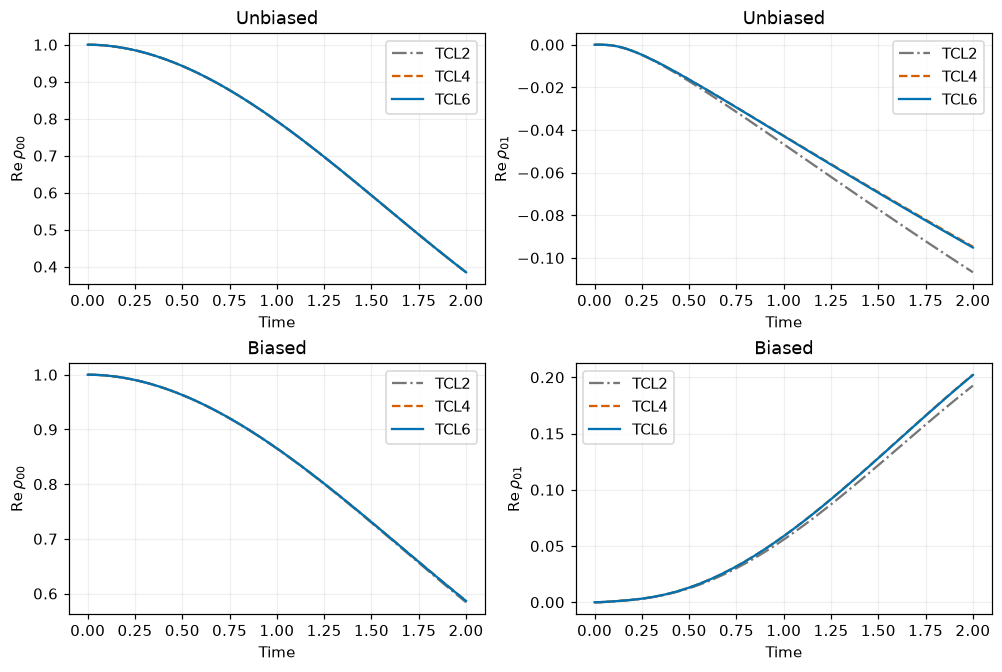

In [4]:
styles = {2: {"color": "#777777", "linestyle": "-."},
          4: {"color": "#D55E00", "linestyle": "--"},
          6: {"color": "#0072B2", "linestyle": "-"}}
fig, axes = plt.subplots(2, 2, figsize=(9, 6), layout="constrained")
for row, (name, result) in enumerate(results.items()):
    for order, rho in result.trajectories.items():
        axes[row, 0].plot(result.times, rho[:, 0, 0].real, label=f"TCL{order}", **styles[order])
        axes[row, 1].plot(result.times, rho[:, 0, 1].real, label=f"TCL{order}", **styles[order])
    axes[row, 0].set_ylabel(r"$\mathrm{Re}\,\rho_{00}$")
    axes[row, 1].set_ylabel(r"$\mathrm{Re}\,\rho_{01}$")
    for ax in axes[row]:
        ax.set(title=name, xlabel="Time")
        ax.grid(alpha=0.2)
        ax.legend()
plt.show()

## Changes between orders and numerical diagnostics

The Frobenius differences below show how the prediction changes when another TCL order is included. They are not error bounds against exact dynamics. Trace and Hermiticity should be preserved to numerical precision; a finite TCL truncation does not guarantee positivity.

In [5]:
for name, result in results.items():
    curves = result.trajectories
    change_24 = np.linalg.norm(curves[4] - curves[2], axis=(1, 2)).max()
    change_46 = np.linalg.norm(curves[6] - curves[4], axis=(1, 2)).max()
    print(f"{name}: max ||rho4-rho2|| = {change_24:.3e}; max ||rho6-rho4|| = {change_46:.3e}")
    for order, rho in curves.items():
        trace_error = np.max(np.abs(np.trace(rho, axis1=1, axis2=2) - 1))
        hermiticity_error = np.max(np.abs(rho - rho.conj().transpose(0, 2, 1)))
        assert np.isfinite(rho).all()
        assert trace_error < 1e-10
        assert hermiticity_error < 1e-10
        print(f"  TCL{order}: trace error {trace_error:.2e}, Hermiticity error {hermiticity_error:.2e}")

Unbiased: max ||rho4-rho2|| = 1.699e-02; max ||rho6-rho4|| = 6.954e-04
  TCL2: trace error 4.45e-16, Hermiticity error 1.06e-16
  TCL4: trace error 8.88e-16, Hermiticity error 1.22e-16
  TCL6: trace error 5.55e-16, Hermiticity error 1.08e-16
Biased: max ||rho4-rho2|| = 1.580e-02; max ||rho6-rho4|| = 8.699e-04
  TCL2: trace error 4.45e-16, Hermiticity error 1.39e-16
  TCL4: trace error 6.66e-16, Hermiticity error 1.24e-16
  TCL6: trace error 2.23e-16, Hermiticity error 1.24e-16


## A short grid-refinement check

Halve the output step while keeping the same final time. This check uses TCL4 so it runs quickly. `solve` calculates the generator at the required midpoint times for every RK4 step.

Comparing a sequence of finer grids is needed to assess time-step accuracy for a chosen model and time interval.

Maximum TCL4 difference on common times: 4.919e-05


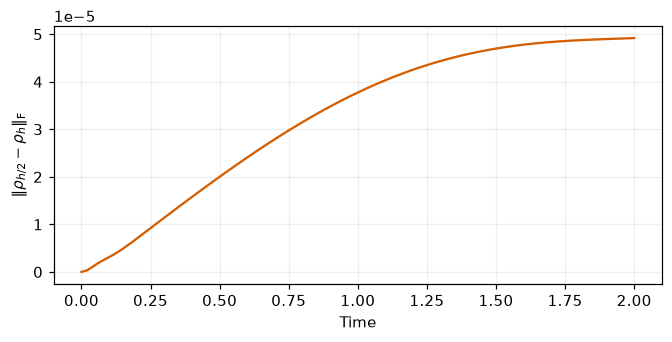

In [6]:
finer = solve(models["Unbiased"], bath, rho0,
              dt=dt / 2, n_steps=2 * n_steps,
              coupling_strength=lambda_value, order=4)
coarse = results["Unbiased"]
np.testing.assert_allclose(finer.times[::2], coarse.times, atol=1e-14, rtol=0)
grid_difference = np.linalg.norm(finer.trajectories[4][::2] - coarse.trajectories[4], axis=(1, 2))
print(f"Maximum TCL4 difference on common times: {grid_difference.max():.3e}")
fig, ax = plt.subplots(figsize=(6, 3), layout="constrained")
ax.plot(coarse.times, grid_difference, color="#D55E00")
ax.set(xlabel="Time", ylabel=r"$\|\rho_{h/2}-\rho_h\|_{\mathrm{F}}$")
ax.grid(alpha=0.2)
plt.show()

## Try another calculation

- Change `lambda_value`, `omega_c`, or either Hamiltonian, then rerun the dependent cells.
- For a lower-order-only run, omit the `plans` construction and the `plan=` argument, then call `solve(..., order=2)` or `solve(..., order=4)`. This avoids preparing TCL6.
- Use the second notebook to supply your own correlation samples and inspect the separate generator contributions.

For full conventions, see [`../docs/conventions.md`](../docs/conventions.md). The accepted numerical figures can be replotted with `python reproduce/replot.py` from the repository root.